In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [4]:
df = pd.read_excel("Online Retail.xlsx")
df.head()
df.shape
df.columns
df.info()
df.isnull().sum()
df.duplicated().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [5]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [6]:
df.duplicated().sum()

np.int64(5268)

In [7]:
(df['Quantity'] < 0).sum()

np.int64(10624)

In [8]:
df[df['Quantity'] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [9]:
(df['UnitPrice'] < 0).sum()

np.int64(2)

In [10]:
df[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [11]:
df['InvoiceNo'].astype(str).str.startswith('C').value_counts()

,count
InvoiceNo,
False,532621
True,9288


In [12]:
df['CustomerID'].nunique()

4372

In [13]:
df_clean = df.copy()

In [14]:
df_clean = df_clean.dropna(subset=['CustomerID'])

In [15]:
df_clean['CustomerID'].isnull().sum()

np.int64(0)

In [16]:
df_clean = df_clean.drop_duplicates()

In [17]:
df_clean = df_clean[df_clean['Quantity'] > 0]

In [18]:
df_clean = df_clean[df_clean['UnitPrice'] > 0]

In [19]:
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

In [20]:
df_clean['Revenue'] = (
    df_clean['Quantity'] * df_clean['UnitPrice']
)

In [21]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [22]:
df_clean.shape

(392692, 9)

In [23]:
df_clean.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Revenue,0


In [24]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [25]:
df_clean.duplicated().sum()

np.int64(0)

In [26]:
df_clean['Revenue'].describe()

,Revenue
count,392692.000000
mean,22.631500
std,311.099224
min,0.001000
25%,4.950000
50%,12.450000
75%,19.800000
max,168469.600000


In [27]:
df_clean['Revenue'].min()

0.001

In [28]:
df_clean.to_csv(
    'online_retail_cleaned.csv',
    index=False
)

In [29]:
from google.colab import files

files.download('online_retail_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. Exploratory Data Analysis


In [30]:
total_revenue = df_clean['Revenue'].sum()

print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £8,887,208.89


In [31]:
total_orders = df_clean['InvoiceNo'].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 18,532


In [32]:
total_customers = df_clean['CustomerID'].nunique()

print(f"Total Customers: {total_customers:,}")

Total Customers: 4,338


In [33]:
total_quantity = df_clean['Quantity'].sum()

print(f"Total Quantity Sold: {total_quantity:,}")

Total Quantity Sold: 5,152,002


In [34]:
average_order_value = total_revenue / total_orders

print(f"Average Order Value: £{average_order_value:,.2f}")

Average Order Value: £479.56


In [35]:
country_revenue = (
    df_clean.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

,Revenue
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


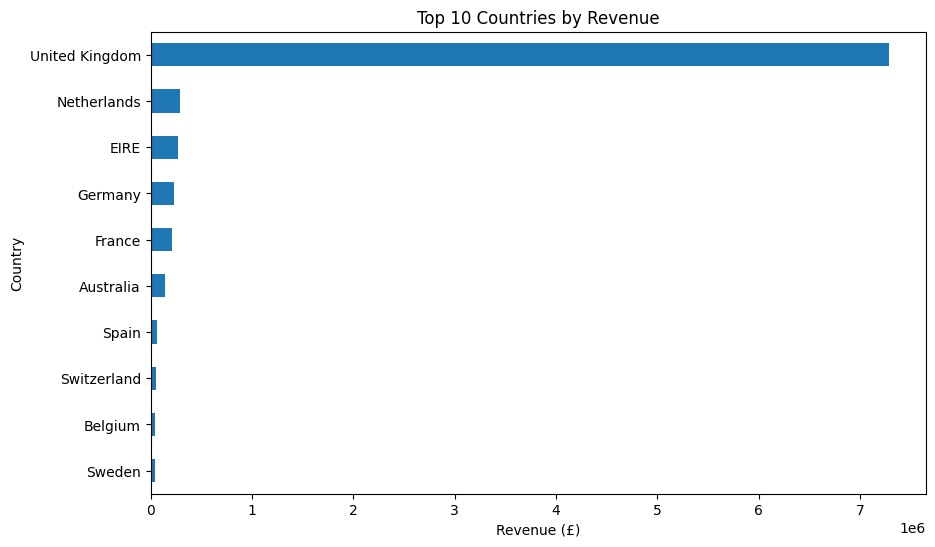

In [36]:
plt.figure(figsize=(10, 6))

country_revenue.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Country')

plt.show()

In [37]:
country_orders = (
    df_clean.groupby('Country')['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
)

country_orders.head(10)

,InvoiceNo
Country,
United Kingdom,16646
Germany,457
France,389
EIRE,260
Belgium,98
Netherlands,94
Spain,90
Portugal,57
Australia,57


In [38]:
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

In [39]:
monthly_revenue = (
    df_clean.groupby('YearMonth')['Revenue']
    .sum()
)

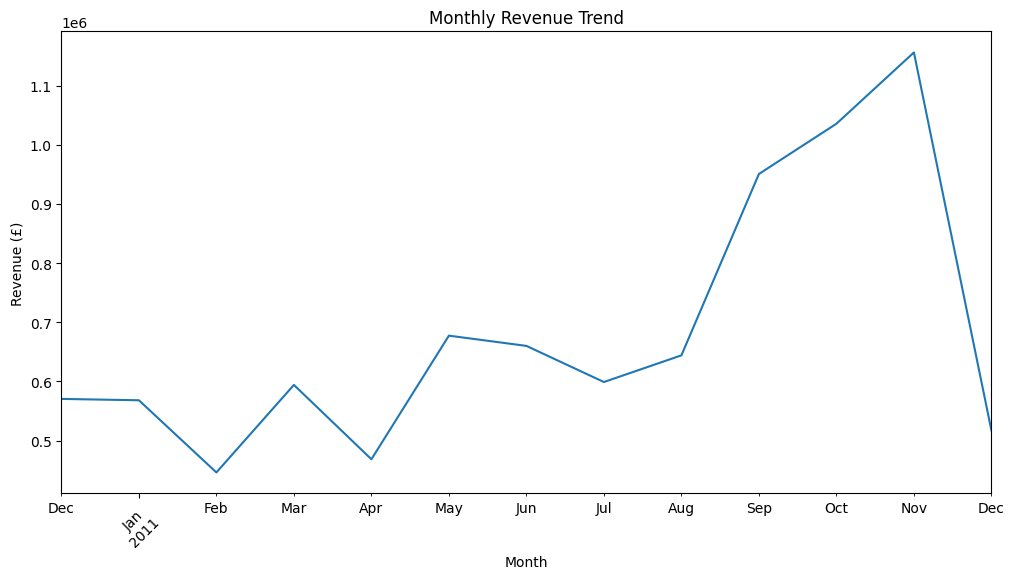

In [40]:
plt.figure(figsize=(12, 6))

monthly_revenue.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')

plt.xticks(rotation=45)

plt.show()

In [41]:
product_revenue = (
    df_clean.groupby(['StockCode', 'Description'])['Revenue']
    .sum()
    .sort_values(ascending=False)
)

product_revenue.head(10)

,,Revenue
StockCode,Description,
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
22423,REGENCY CAKESTAND 3 TIER,142264.75
85123A,WHITE HANGING HEART T-LIGHT HOLDER,100392.10
85099B,JUMBO BAG RED RETROSPOT,85040.54
23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POST,POSTAGE,77803.96
47566,PARTY BUNTING,68785.23
84879,ASSORTED COLOUR BIRD ORNAMENT,56413.03
M,Manual,53419.93


In [42]:
customer_revenue = (
    df_clean.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

,Revenue
CustomerID,
14646,280206.02
18102,259657.30
17450,194390.79
16446,168472.50
14911,143711.17
12415,124914.53
14156,117210.08
17511,91062.38
16029,80850.84


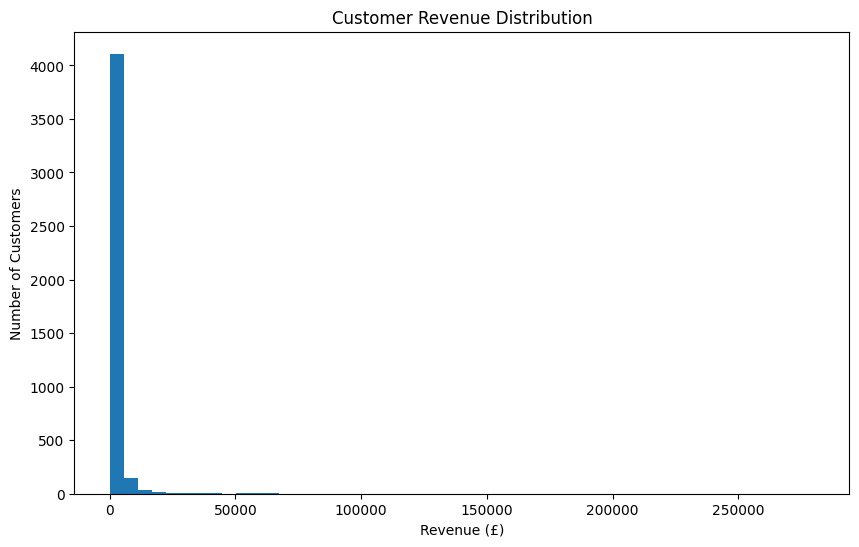

In [43]:
plt.figure(figsize=(10, 6))

customer_revenue.plot(kind='hist', bins=50)

plt.title('Customer Revenue Distribution')
plt.xlabel('Revenue (£)')
plt.ylabel('Number of Customers')

plt.show()

In [44]:
df_clean.nlargest(10, 'Revenue')[
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'CustomerID', 'Country', 'Revenue']
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446,United Kingdom,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346,United Kingdom,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,15098,United Kingdom,38970.00
173382,551697,POST,POSTAGE,1,8142.75,16029,United Kingdom,8142.75
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,17450,United Kingdom,7144.72
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749,United Kingdom,6539.40
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749,United Kingdom,6539.40
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,14646,Netherlands,4992.00
52709,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.55,15749,United Kingdom,4921.50
160542,550461,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.40,15749,United Kingdom,4632.00


In [45]:
df_clean.nlargest(10, 'Quantity')[
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'CustomerID', 'Country', 'Revenue']
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446,United Kingdom,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346,United Kingdom,77183.60
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,12901,United Kingdom,1008.00
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,13135,United Kingdom,3096.00
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,18087,United Kingdom,3202.92
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,14609,United Kingdom,191.16
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749,United Kingdom,6539.40
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749,United Kingdom,6539.40
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,16308,United Kingdom,960.00
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,0.18,16754,United Kingdom,518.40


In [46]:
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Quantity: {total_quantity:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

Total Revenue: £8,887,208.89
Total Orders: 18,532
Total Customers: 4,338
Total Quantity: 5,152,002
Average Order Value: £479.56


In [47]:
country_revenue.head(10)

,Revenue
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


In [48]:
customer_revenue.head(10)

,Revenue
CustomerID,
14646,280206.02
18102,259657.30
17450,194390.79
16446,168472.50
14911,143711.17
12415,124914.53
14156,117210.08
17511,91062.38
16029,80850.84


In [49]:
df_clean.nlargest(10, 'Revenue')[
    ['InvoiceNo', 'Description', 'Quantity',
     'UnitPrice', 'CustomerID', 'Revenue']
]

,InvoiceNo,Description,Quantity,UnitPrice,CustomerID,Revenue
540421,581483,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446,168469.60
61619,541431,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346,77183.60
222680,556444,PICNIC BASKET WICKER 60 PIECES,60,649.50,15098,38970.00
173382,551697,POSTAGE,1,8142.75,16029,8142.75
348325,567423,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,17450,7144.72
52711,540815,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749,6539.40
160546,550461,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749,6539.40
421601,573003,RABBIT NIGHT LIGHT,2400,2.08,14646,4992.00
52709,540815,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.55,15749,4921.50
160542,550461,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.40,15749,4632.00


In [50]:
df_clean.nlargest(10, 'Quantity')[
    ['InvoiceNo', 'Description', 'Quantity',
     'UnitPrice', 'CustomerID', 'Revenue']
]

,InvoiceNo,Description,Quantity,UnitPrice,CustomerID,Revenue
540421,581483,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446,168469.60
61619,541431,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346,77183.60
421632,573008,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,12901,1008.00
206121,554868,SMALL POPCORN HOLDER,4300,0.72,13135,3096.00
97432,544612,EMPIRE DESIGN ROSETTE,3906,0.82,18087,3202.92
270885,560599,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,14609,191.16
52711,540815,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749,6539.40
160546,550461,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749,6539.40
433788,573995,SMALL CHINESE STYLE SCISSOR,3000,0.32,16308,960.00
4945,536830,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,0.18,16754,518.40


In [51]:
df_clean['Description'].value_counts().head(30)

,count
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2016
REGENCY CAKESTAND 3 TIER,1713
JUMBO BAG RED RETROSPOT,1615
ASSORTED COLOUR BIRD ORNAMENT,1395
PARTY BUNTING,1389
LUNCH BAG RED RETROSPOT,1303
SET OF 3 CAKE TINS PANTRY DESIGN,1152
POSTAGE,1099
LUNCH BAG BLACK SKULL.,1078


In [52]:
df_clean['StockCode'].value_counts().head(30)

,count
StockCode,
85123A,2023
22423,1713
85099B,1615
84879,1395
47566,1389
20725,1304
22720,1152
POST,1099
23203,1091


In [53]:
df_clean[
    df_clean['Description'].str.contains(
        'POSTAGE|BANK CHARGES|DISCOUNT|MANUAL',
        case=False,
        na=False
    )
][[
    'InvoiceNo',
    'StockCode',
    'Description',
    'Quantity',
    'UnitPrice',
    'CustomerID',
    'Revenue'
]].head(30)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Revenue
45,536370,POST,POSTAGE,3,18.00,12583,54.00
386,536403,POST,POSTAGE,1,15.00,12791,15.00
1123,536527,POST,POSTAGE,1,18.00,12662,18.00
2239,536569,M,Manual,1,1.25,16274,1.25
2250,536569,M,Manual,1,18.95,16274,18.95
4406,536779,BANK CHARGES,Bank Charges,1,15.00,15823,15.00
5073,536840,POST,POSTAGE,1,18.00,12738,18.00
5258,536852,POST,POSTAGE,1,18.00,12686,18.00
5325,536858,POST,POSTAGE,2,40.00,13520,80.00
5369,536861,POST,POSTAGE,3,18.00,12427,54.00


In [54]:
special_items = df_clean[
    df_clean['Description'].str.contains(
        'POSTAGE|BANK CHARGES|DISCOUNT|MANUAL',
        case=False,
        na=False
    )
]

print("Special rows:", len(special_items))
print("Special revenue: £{:,.2f}".format(
    special_items['Revenue'].sum()
))

Special rows: 1406
Special revenue: £143,295.25


In [55]:
special_items.groupby('Description')['Revenue'].agg(
    ['count', 'sum']
).sort_values('sum', ascending=False)

,count,sum
Description,,
POSTAGE,1099,77803.960
Manual,279,53419.930
DOTCOM POSTAGE,16,11906.360
Bank Charges,12,165.001


In [56]:
df_clean[
    df_clean['CustomerID'].isin([14646, 18102, 17450, 16446, 12346])
].groupby('CustomerID').agg(
    Orders=('InvoiceNo', 'nunique'),
    Quantity=('Quantity', 'sum'),
    Revenue=('Revenue', 'sum')
).sort_values('Revenue', ascending=False)

,Orders,Quantity,Revenue
CustomerID,,,
14646,73,196915,280206.02
18102,60,64124,259657.30
17450,46,69973,194390.79
16446,2,80997,168472.50
12346,1,74215,77183.60


## Preparing Data for Customer Segmentation

In [57]:
df_analysis = df_clean[
    ~df_clean['Description'].str.contains(
        'POSTAGE|BANK CHARGES|MANUAL',
        case=False,
        na=False
    )
].copy()

In [58]:
print("Original cleaned transactions:", len(df_clean))
print("Transactions used for segmentation:", len(df_analysis))
print("Transactions excluded:", len(df_clean) - len(df_analysis))

Original cleaned transactions: 392692
Transactions used for segmentation: 391286
Transactions excluded: 1406


In [59]:
print(
    f"Revenue before removing special transactions: "
    f"£{df_clean['Revenue'].sum():,.2f}"
)

print(
    f"Revenue used for segmentation: "
    f"£{df_analysis['Revenue'].sum():,.2f}"
)

Revenue before removing special transactions: £8,887,208.89
Revenue used for segmentation: £8,743,913.64


In [60]:
df_analysis['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [61]:
analysis_date = df_analysis['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Analysis Date:", analysis_date)

Analysis Date: 2011-12-10 12:50:00


In [62]:
rfm = df_analysis.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (analysis_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

In [63]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1437.24
3,12349,19,1,1457.55
4,12350,310,1,294.40


In [64]:
rfm['AverageOrderValue'] = (
    rfm['Monetary'] / rfm['Frequency']
)

In [65]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,AverageOrderValue
0,12346,326,1,77183.60,77183.600000
1,12347,2,7,4310.00,615.714286
2,12348,75,4,1437.24,359.310000
3,12349,19,1,1457.55,1457.550000
4,12350,310,1,294.40,294.400000


In [66]:
rfm.shape

(4334, 5)

In [67]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary,AverageOrderValue
count,4334.000000,4334.000000,4334.000000,4334.000000,4334.000000
mean,15299.251731,92.703046,4.246654,2017.515838,415.673277
std,1721.994109,100.177047,7.642535,8920.363571,1800.858885
min,12346.000000,1.000000,1.000000,3.750000,3.750000
25%,13812.250000,18.000000,1.000000,304.305000,177.197500
50%,15297.500000,51.000000,2.000000,663.710000,289.770000
75%,16778.750000,143.000000,5.000000,1631.622500,423.770750
max,18287.000000,374.000000,206.000000,279138.020000,84236.250000


In [68]:
rfm.isnull().sum()

,0
CustomerID,0
Recency,0
Frequency,0
Monetary,0
AverageOrderValue,0


In [69]:
rfm.duplicated().sum()

np.int64(0)

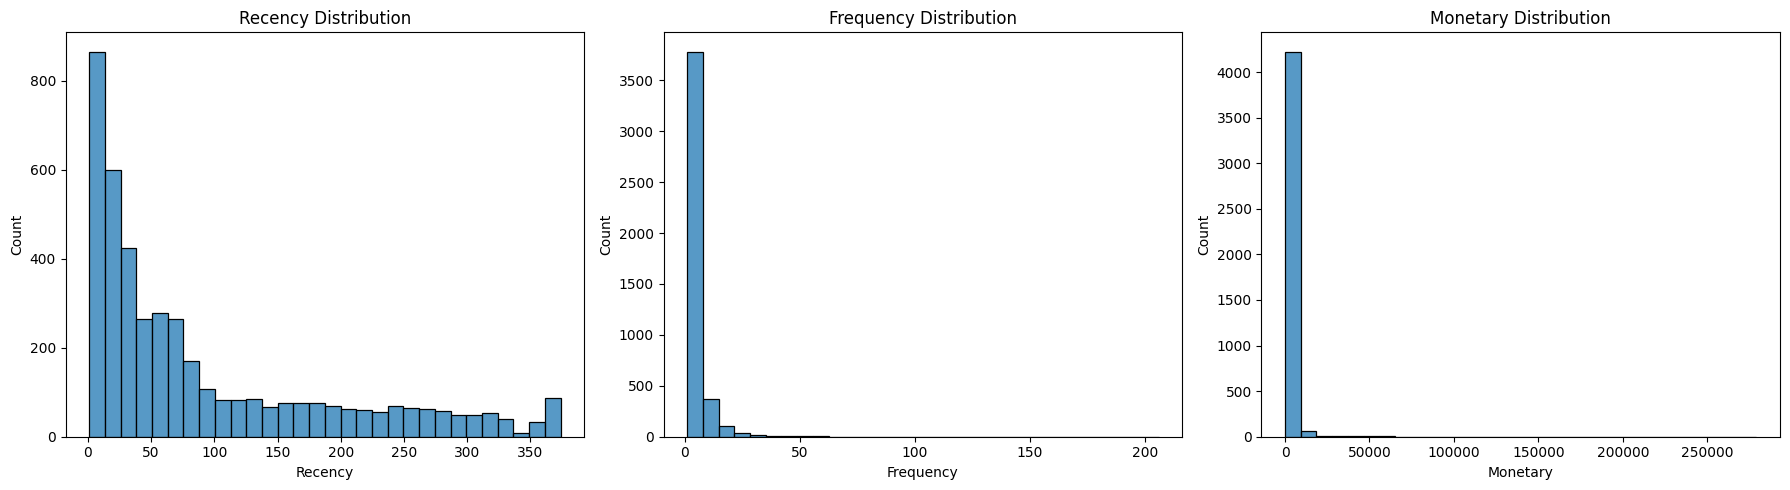

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], bins=30, ax=axes[0])
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], bins=30, ax=axes[1])
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], bins=30, ax=axes[2])
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

In [71]:
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,AverageOrderValue
0,12346,326,1,77183.60,77183.600000
1,12347,2,7,4310.00,615.714286
2,12348,75,4,1437.24,359.310000
3,12349,19,1,1457.55,1457.550000
4,12350,310,1,294.40,294.400000
5,12352,36,7,1385.74,197.962857
6,12353,204,1,89.00,89.000000
7,12354,232,1,1079.40,1079.400000
8,12355,214,1,459.40,459.400000
9,12356,23,3,2487.43,829.143333


In [72]:
rfm[['Recency', 'Frequency', 'Monetary']].skew()

,0
Recency,1.242934
Frequency,11.976299
Monetary,19.551828


In [73]:
rfm[['Recency', 'Frequency', 'Monetary']].quantile(
    [0.90, 0.95, 0.99, 1.00]
)

,Recency,Frequency,Monetary
0.90,263.0,9.0,3560.0800
0.95,312.0,13.0,5735.2155
0.99,369.0,30.0,18715.3130
1.00,374.0,206.0,279138.0200


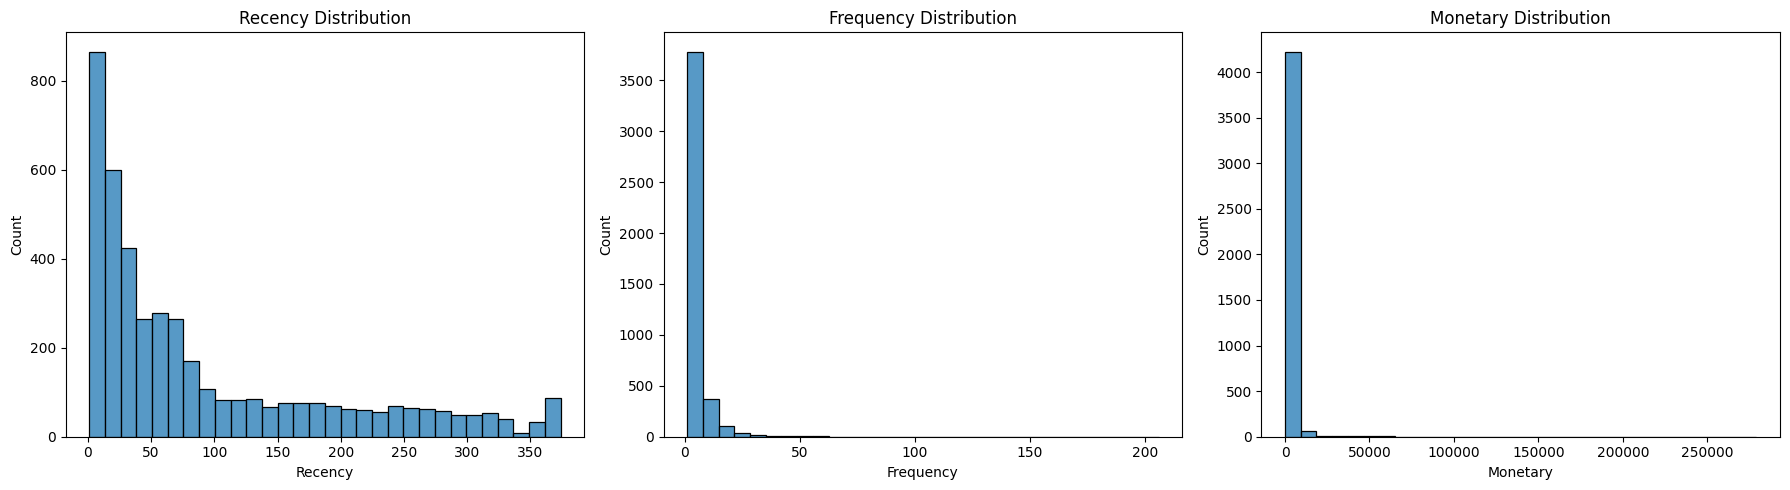

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], bins=30, ax=axes[0])
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], bins=30, ax=axes[1])
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], bins=30, ax=axes[2])
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

In [75]:
rfm_model = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary']].copy()

In [76]:
rfm_model[['Recency', 'Frequency', 'Monetary']] = np.log1p(
    rfm_model[['Recency', 'Frequency', 'Monetary']]
)

In [77]:
print("Original skewness:")
print(rfm[['Recency', 'Frequency', 'Monetary']].skew())

print("\nAfter log transformation:")
print(rfm_model[['Recency', 'Frequency', 'Monetary']].skew())

Original skewness:
Recency       1.242934
Frequency    11.976299
Monetary     19.551828
dtype: float64

After log transformation:
Recency     -0.378920
Frequency    1.214115
Monetary     0.400774
dtype: float64


In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_model[['Recency', 'Frequency', 'Monetary']]
)

In [79]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

In [80]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4.334000e+03,4.334000e+03,4.334000e+03
mean,4.606888e-16,-1.467318e-16,-1.639462e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-2.341403e+00,-9.512430e-01,-4.000778e+00
25%,-6.621078e-01,-9.512430e-01,-6.816485e-01
50%,8.889316e-02,-3.565098e-01,-6.134806e-02
75%,8.486698e-01,6.601932e-01,6.550641e-01
max,1.562604e+00,5.854045e+00,4.754198e+00


In [81]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

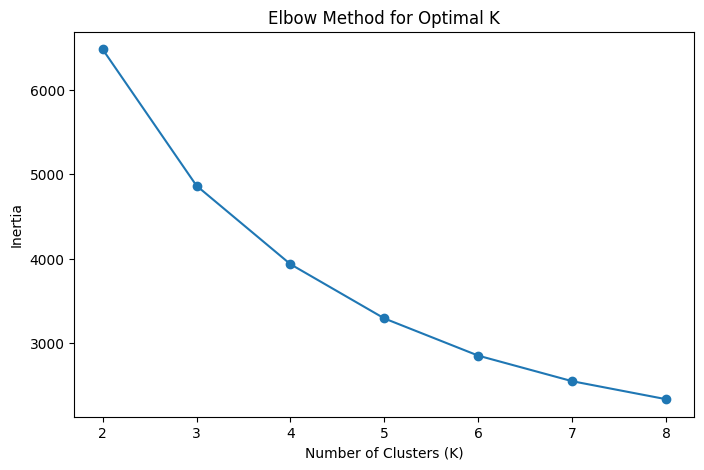

In [82]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')

plt.show()

## Selecting the Optimal Number of Clusters

In [83]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

for k, score in zip(K_range, silhouette_scores):
    print(f"K={k}: Silhouette Score = {score:.4f}")

K=2: Silhouette Score = 0.4329
K=3: Silhouette Score = 0.3376
K=4: Silhouette Score = 0.3378
K=5: Silhouette Score = 0.3166
K=6: Silhouette Score = 0.3137
K=7: Silhouette Score = 0.3090
K=8: Silhouette Score = 0.3020


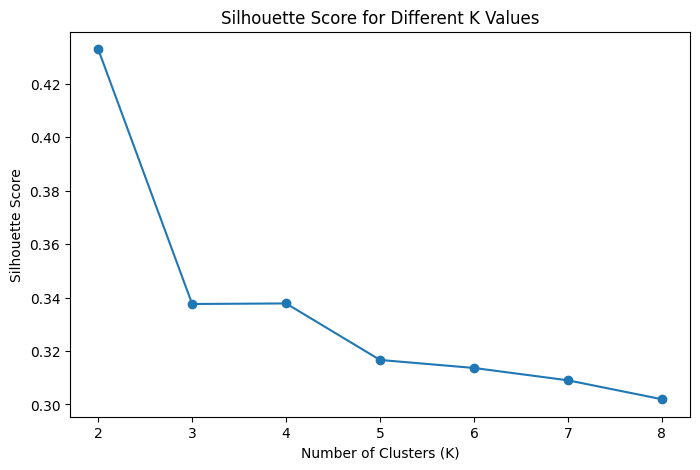

In [84]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')

plt.show()

## K-Means Customer Segmentation

In [85]:
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

rfm['Cluster_2'] = kmeans_2.fit_predict(rfm_scaled)

In [86]:
rfm['Cluster_2'].value_counts().sort_index()

,count
Cluster_2,
0,1664
1,2670


In [87]:
cluster_2_profile = rfm.groupby('Cluster_2').agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Avg_Order_Value=('AverageOrderValue', 'mean')
).round(2)

cluster_2_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Order_Value
Cluster_2,,,,,
0,1664,25.82,8.40,4463.27,564.98
1,2670,134.39,1.66,493.27,322.62


In [88]:
kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster_4'] = kmeans_4.fit_predict(rfm_scaled)

In [89]:
cluster_4_profile = rfm.groupby('Cluster_4').agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Avg_Order_Value=('AverageOrderValue', 'mean')
).round(2)

cluster_4_profile


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Order_Value
Cluster_4,,,,,
0,840,18.53,2.10,531.77,276.78
1,1636,183.10,1.33,351.64,287.74
2,1174,67.00,4.18,1809.10,571.41
3,684,11.70,13.96,8184.31,624.93


In [90]:
cluster_4_profile_revenue = rfm.groupby('Cluster_4').agg(
    Customers=('CustomerID', 'count'),
    Total_Revenue=('Monetary', 'sum'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Avg_Order_Value=('AverageOrderValue', 'mean')
).round(2)

cluster_4_profile_revenue

,Customers,Total_Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Order_Value
Cluster_4,,,,,,
0,840,446683.58,18.53,2.10,531.77,276.78
1,1636,575280.61,183.10,1.33,351.64,287.74
2,1174,2123880.77,67.00,4.18,1809.10,571.41
3,684,5598068.68,11.70,13.96,8184.31,624.93


In [91]:
cluster_4_profile_revenue['Customer_Percentage'] = (
    cluster_4_profile_revenue['Customers']
    / len(rfm) * 100
).round(2)

In [92]:
cluster_4_profile_revenue['Revenue_Percentage'] = (
    cluster_4_profile_revenue['Total_Revenue']
    / cluster_4_profile_revenue['Total_Revenue'].sum()
    * 100
).round(2)

In [93]:
cluster_4_profile_revenue

,Customers,Total_Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Order_Value,Customer_Percentage,Revenue_Percentage
Cluster_4,,,,,,,,
0,840,446683.58,18.53,2.10,531.77,276.78,19.38,5.11
1,1636,575280.61,183.10,1.33,351.64,287.74,37.75,6.58
2,1174,2123880.77,67.00,4.18,1809.10,571.41,27.09,24.29
3,684,5598068.68,11.70,13.96,8184.31,624.93,15.78,64.02


In [94]:
cluster_2_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Order_Value
Cluster_2,,,,,
0,1664,25.82,8.40,4463.27,564.98
1,2670,134.39,1.66,493.27,322.62


In [95]:
segment_mapping = {
    0: 'Potential Customers',
    1: 'At-Risk Customers',
    2: 'Loyal Customers',
    3: 'VIP Customers'
}

rfm['Segment'] = rfm['Cluster_4'].map(segment_mapping)

In [96]:
rfm[['CustomerID', 'Recency', 'Frequency',
     'Monetary', 'AverageOrderValue', 'Segment']].head(20)

,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,Segment
0,12346,326,1,77183.60,77183.600000,Loyal Customers
1,12347,2,7,4310.00,615.714286,VIP Customers
2,12348,75,4,1437.24,359.310000,Loyal Customers
3,12349,19,1,1457.55,1457.550000,Potential Customers
4,12350,310,1,294.40,294.400000,At-Risk Customers
5,12352,36,7,1385.74,197.962857,Loyal Customers
6,12353,204,1,89.00,89.000000,At-Risk Customers
7,12354,232,1,1079.40,1079.400000,At-Risk Customers
8,12355,214,1,459.40,459.400000,At-Risk Customers
9,12356,23,3,2487.43,829.143333,Loyal Customers


In [97]:
segment_summary = rfm.groupby('Segment').agg(
    Customers=('CustomerID', 'count'),
    Total_Revenue=('Monetary', 'sum'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Avg_Order_Value=('AverageOrderValue', 'mean')
).round(2)

In [98]:
segment_summary['Customer_Percentage'] = (
    segment_summary['Customers'] / len(rfm) * 100
).round(2)

segment_summary['Revenue_Percentage'] = (
    segment_summary['Total_Revenue']
    / segment_summary['Total_Revenue'].sum() * 100
).round(2)

segment_summary

,Customers,Total_Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Order_Value,Customer_Percentage,Revenue_Percentage
Segment,,,,,,,,
At-Risk Customers,1636,575280.61,183.10,1.33,351.64,287.74,37.75,6.58
Loyal Customers,1174,2123880.77,67.00,4.18,1809.10,571.41,27.09,24.29
Potential Customers,840,446683.58,18.53,2.10,531.77,276.78,19.38,5.11
VIP Customers,684,5598068.68,11.70,13.96,8184.31,624.93,15.78,64.02


In [99]:
segment_order = [
    'VIP Customers',
    'Loyal Customers',
    'Potential Customers',
    'At-Risk Customers'
]

rfm['Segment'] = pd.Categorical(
    rfm['Segment'],
    categories=segment_order,
    ordered=True
)

In [100]:
segment_summary = rfm.groupby(
    'Segment',
    observed=True
).agg(
    Customers=('CustomerID', 'count'),
    Total_Revenue=('Monetary', 'sum'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Avg_Order_Value=('AverageOrderValue', 'mean')
).round(2)

segment_summary

,Customers,Total_Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Order_Value
Segment,,,,,,
VIP Customers,684,5598068.68,11.70,13.96,8184.31,624.93
Loyal Customers,1174,2123880.77,67.00,4.18,1809.10,571.41
Potential Customers,840,446683.58,18.53,2.10,531.77,276.78
At-Risk Customers,1636,575280.61,183.10,1.33,351.64,287.74


In [101]:
customer_segments = rfm[
    [
        'CustomerID',
        'Recency',
        'Frequency',
        'Monetary',
        'AverageOrderValue',
        'Segment'
    ]
].copy()

In [102]:
customer_segments.head()

,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,Segment
0,12346,326,1,77183.60,77183.600000,Loyal Customers
1,12347,2,7,4310.00,615.714286,VIP Customers
2,12348,75,4,1437.24,359.310000,Loyal Customers
3,12349,19,1,1457.55,1457.550000,Potential Customers
4,12350,310,1,294.40,294.400000,At-Risk Customers


In [103]:
customer_segments.shape

(4334, 6)

In [104]:
customer_segments.to_csv(
    'customer_segments.csv',
    index=False
)

In [105]:
files.download('customer_segments.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [106]:
# Find the 4 customers missing from RFM
missing_ids = [15802, 15823, 16742, 17846]

missing_data = df_clean[
    df_clean['CustomerID'].isin(missing_ids)
].copy()

# Calculate RFM for them
missing_rfm = missing_data.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x:
             (df_clean['InvoiceDate'].max() - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

# Average Order Value
missing_rfm['AverageOrderValue'] = (
    missing_rfm['Monetary'] / missing_rfm['Frequency']
)

missing_rfm

,CustomerID,Recency,Frequency,Monetary,AverageOrderValue
0,15802,142,1,451.42,451.42
1,15823,371,1,15.00,15.00
2,16742,46,1,464.90,464.90
3,17846,84,1,2033.10,2033.10


In [107]:
missing_features = missing_rfm[
    ['Recency', 'Frequency', 'Monetary']
].copy()

missing_log = np.log1p(missing_features)

missing_scaled = scaler.transform(missing_log)

In [108]:
missing_rfm['Cluster_4'] = kmeans_4.predict(missing_scaled)

missing_rfm

,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,Cluster_4
0,15802,142,1,451.42,451.42,1
1,15823,371,1,15.00,15.00,1
2,16742,46,1,464.90,464.90,1
3,17846,84,1,2033.10,2033.10,2


In [109]:
segment_mapping = {
    0: 'Potential Customers',
    1: 'At-Risk Customers',
    2: 'Loyal Customers',
    3: 'VIP Customers'
}

missing_rfm['Segment'] = missing_rfm['Cluster_4'].map(segment_mapping)

missing_rfm

,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,Cluster_4,Segment
0,15802,142,1,451.42,451.42,1,At-Risk Customers
1,15823,371,1,15.00,15.00,1,At-Risk Customers
2,16742,46,1,464.90,464.90,1,At-Risk Customers
3,17846,84,1,2033.10,2033.10,2,Loyal Customers


In [110]:
rfm = pd.concat(
    [rfm, missing_rfm],
    ignore_index=True
)

In [111]:
rfm.shape

(4338, 8)

In [112]:
customer_segments = rfm[
    [
        'CustomerID',
        'Recency',
        'Frequency',
        'Monetary',
        'AverageOrderValue',
        'Segment'
    ]
].copy()

customer_segments.to_csv(
    'customer_segments.csv',
    index=False
)

In [113]:
files.download('customer_segments.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>